## Path configuration

In [ ]:
from pathlib import Path
import os

PROJECT_NAME = "MALDIAlign"

cwd = Path().resolve()

# Walk upwards until we find the project folder
target = None
for parent in [cwd] + list(cwd.parents):
    if parent.name == PROJECT_NAME:
        target = parent
        break

# If the project folder is found and we are not already there, then change cwd
if target is not None and target != cwd:
    os.chdir(target)

print("Working directory:", os.getcwd())

Working directory: /export/usuarios01/agnavarr/MALDIAlign


## Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from utils.config import load_config
from utils.data import load_pkl
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, trustworthiness
from sklearn.utils import resample

## Data loading

In [ ]:
cfg = load_config()
marisma_pkl = cfg["data"]["MARISMa_REDUCED_PKL"]

In [ ]:
marisma = load_pkl(marisma_pkl)

In [ ]:
data, label, meta = marisma["data"], marisma["label"], marisma["meta"]

In [ ]:
meta = pd.DataFrame.from_records(list(meta))

## PCA

Normalize each spectrum

In [ ]:
# axis=1 to work row by row
# keepdims=True keeps the dimensions needed for per-row normalization to work correctly
data_norm = (data - data.min(axis=1, keepdims=True)) / (
    data.max(axis=1, keepdims=True) - data.min(axis=1, keepdims=True) + 1e-8)

Reduce dimensionality (there are 6000 features)

In [ ]:
my_pca = PCA().fit(data_norm)

In [ ]:
# explained_variance_ returns the amount of variance explained by each of the selected components
# explained_variance_ratio_ returnd the percentage of variance explained by each of the selected components
cumulative_explained_var = np.cumsum(my_pca.explained_variance_)
cumulative_explained_var_ratio = np.cumsum(my_pca.explained_variance_ratio_)

In [ ]:
print(cumulative_explained_var)
print(cumulative_explained_var_ratio)

[22.05654523 37.97864638 46.11430022 ... 98.57128616 98.57128616
 98.57128617]
[0.22376238 0.38529117 0.46782691 ... 1.         1.         1.        ]


Text(0, 0.5, 'Cumulative explained variance')

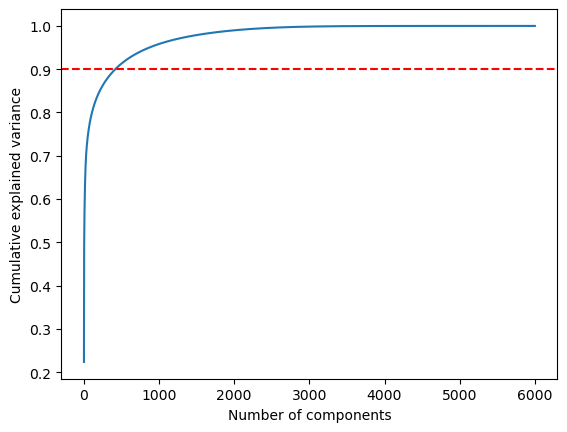

In [ ]:
plt.plot(np.arange(1, len(cumulative_explained_var_ratio)+1), cumulative_explained_var_ratio)
plt.axhline(0.9, color='r', linestyle='--')
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")

In [ ]:
n_components = np.argmax(cumulative_explained_var_ratio >= 0.9) + 1
print(f"Number of components explaining 90% variance: {n_components}")

Number of components explaining 90% variance: 418


This indicates that 418 components are needed to account for 90% of the variance in our dataset. However, this is still a lot for t-SNE, so it is recommended to try and reduce the number of components

In [ ]:
possible_dims = [30, 50, 100]
for dim in possible_dims:
    pca = PCA(n_components=dim).fit(data_norm)
    print(f"Explained variance with {dim} components: {np.sum(pca.explained_variance_ratio_)}")

Explained variance with 30 components: 0.7019925622343979
Explained variance with 50 components: 0.7423888490086569
Explained variance with 100 components: 0.7941803822587071


In [ ]:
data_norm_pca = PCA(n_components=50).fit_transform(data_norm)

## t-SNE

In [ ]:
my_tsne = TSNE(n_components=2)
data_tsne = my_tsne.fit_transform(data_norm_pca)

In [ ]:
n_samples = 10000
X_pca_sub, X_tsne_sub, y_sub = resample(
    data_norm_pca, data_tsne, label, n_samples=n_samples, stratify=label)

tw = trustworthiness(X_pca_sub, X_tsne_sub)
print(f"Trustworthiness (10k stratified sample): {tw:.3f}")

Trustworthiness (10k stratified sample): 0.983


## Visualization

### Label Encoding & DataFrame Creation

In [ ]:
# Identify unique labels
unique_labels = np.unique(label)
print(unique_labels)

# Assign a number to each label
label_to_idx = {}
for i in range(len(unique_labels)):
    label_to_idx[str(unique_labels[i])] = i
print(label_to_idx)

# Map label dataset 
encoded_label = np.array([label_to_idx[l] for l in label])
print(encoded_label)

['Enterobacter_cloacae_complex' 'Enterococcus_Faecium' 'Escherichia_Coli'
 'Klebsiella_Pneumoniae' 'Pseudomonas_Aeruginosa' 'Staphylococcus_Aureus']
{'Enterobacter_cloacae_complex': 0, 'Enterococcus_Faecium': 1, 'Escherichia_Coli': 2, 'Klebsiella_Pneumoniae': 3, 'Pseudomonas_Aeruginosa': 4, 'Staphylococcus_Aureus': 5}
[4 4 4 ... 0 0 0]


In [ ]:
# Create a DataFrame combining coordinates and metadata
tsne_df = pd.DataFrame({
    "x": data_tsne[:, 0],
    "y": data_tsne[:, 1],
    "species": label,
    "year": meta["year"].astype(str), 
    "study": meta["study"].astype(str)
})

tsne_df

,x,y,species,year,study
0,-6.096013,45.279137,Pseudomonas_Aeruginosa,2020,ac9d3149/0_C2/1
1,23.656050,96.294456,Pseudomonas_Aeruginosa,2020,840724c3/0_D7/1
2,-6.850739,96.377098,Pseudomonas_Aeruginosa,2020,840724c3/0_C5/1
3,-22.982811,84.691010,Pseudomonas_Aeruginosa,2020,5db4adbf/0_B11/1
4,-29.608397,61.116550,Pseudomonas_Aeruginosa,2020,8662f7d6/0_A4/1
...,...,...,...,...,...
76167,5.617124,9.103799,Enterobacter_cloacae_complex,2022,991f60fb/0_E3/1
76168,-3.900769,-2.331370,Enterobacter_cloacae_complex,2022,1a44a359-1A/0_C12/1
76169,10.533138,-1.189992,Enterobacter_cloacae_complex,2022,57e2ec67-2/0_A5/1
76170,10.777330,0.440451,Enterobacter_cloacae_complex,2022,6ae3dc2d-2E/0_B10/1


### Palettes and Label Orders

In [ ]:
# Define palettes
tab10 = sns.color_palette("tab10")

species_color_map = {
    "Enterobacter_cloacae_complex": tab10[5],  
    "Enterococcus_Faecium": tab10[4],          
    "Escherichia_Coli": tab10[2],              
    "Klebsiella_Pneumoniae": tab10[3],        
    "Pseudomonas_Aeruginosa": tab10[0],        
    "Staphylococcus_Aureus": tab10[1],       
}

species_sorted = sorted(tsne_df["species"].unique())
years_sorted = sorted(tsne_df["year"].unique(), key=lambda x: int(x))

species_palette_dict = {sp: species_color_map[sp] for sp in species_sorted}

### Global t-SNE — Visualization by Species
Displays the overall t-SNE embedding colored by species to assess inter-species separation in spectral space.


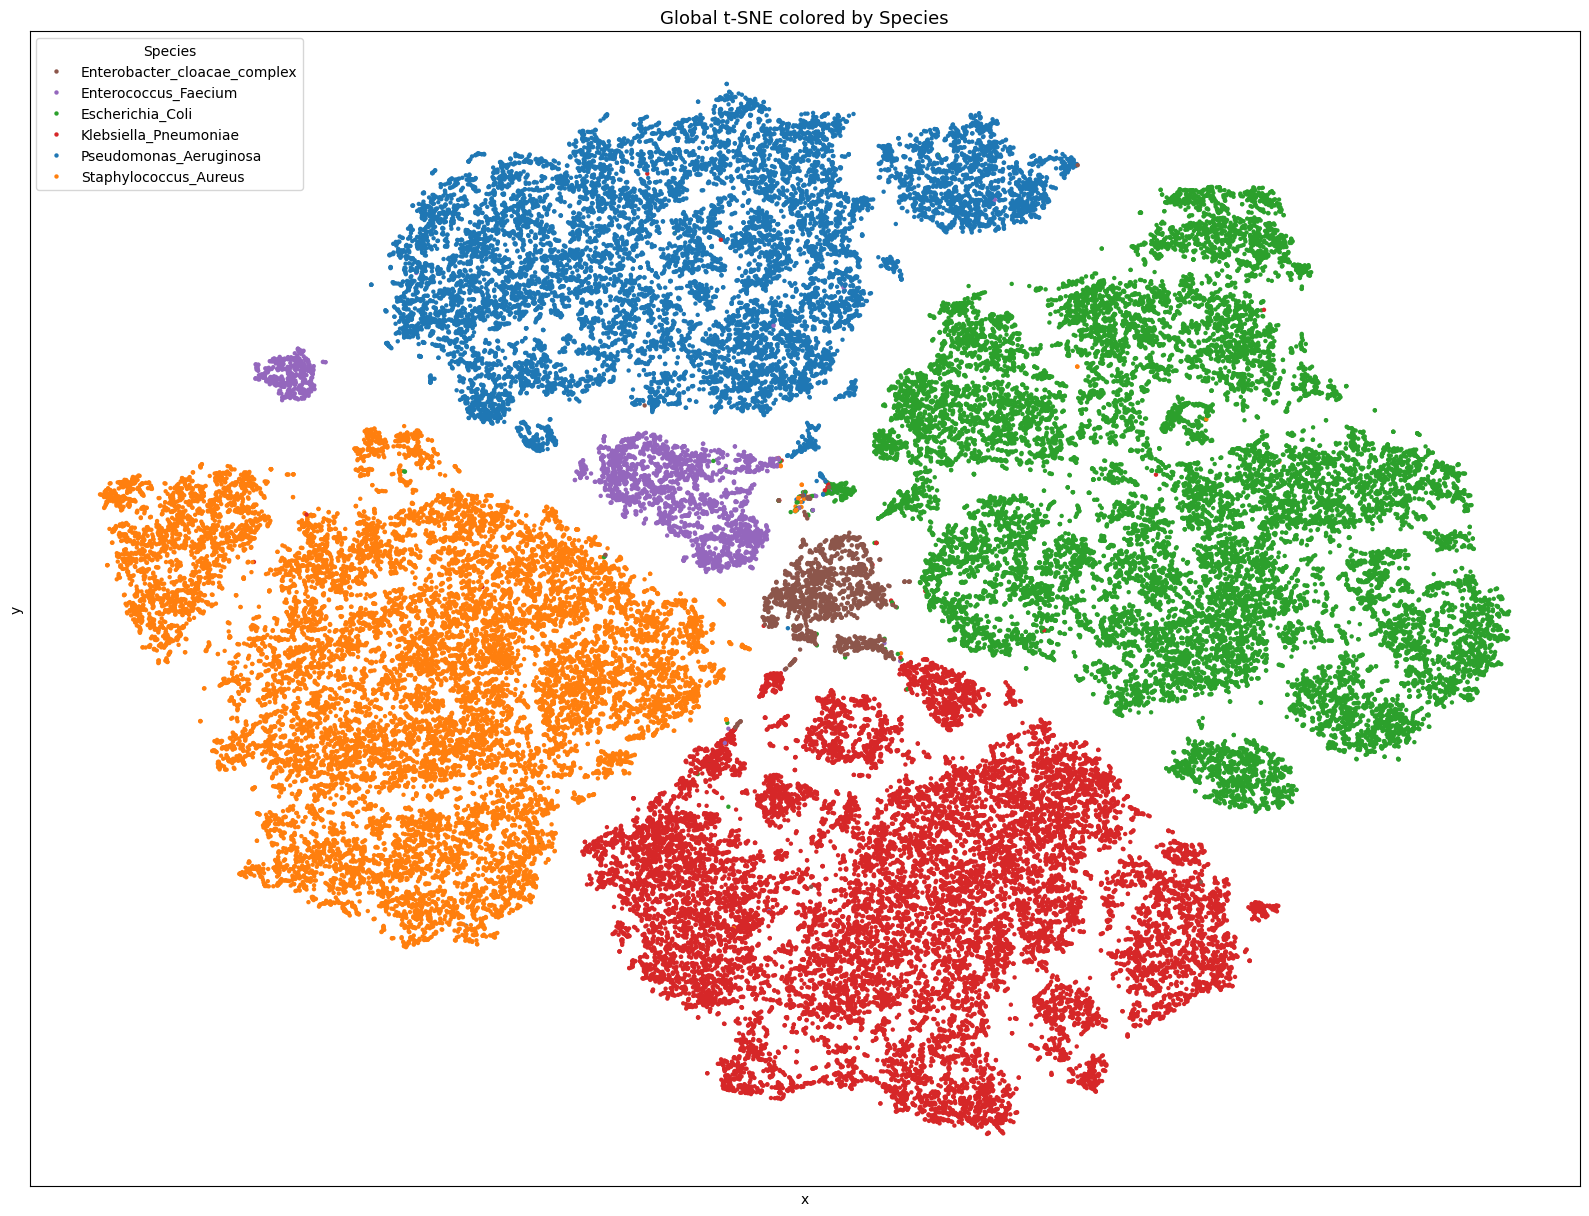

In [ ]:
fig, ax = plt.subplots(figsize=(20, 15))

sns.scatterplot(
    data=tsne_df, x="x", y="y",
    hue="species", hue_order=species_sorted,
    palette=species_palette_dict,
    s=10, linewidth=0, ax=ax
)

ax.set_title("Global t-SNE colored by Species", fontsize=13)
ax.set_xticks([]); ax.set_yticks([])
ax.legend(loc="upper left", title="Species")
plt.show()

### Global t-SNE — Visualization by Year
Shows the global temporal distribution of the dataset, coloring each sample by acquisition year to detect potential time shifts.

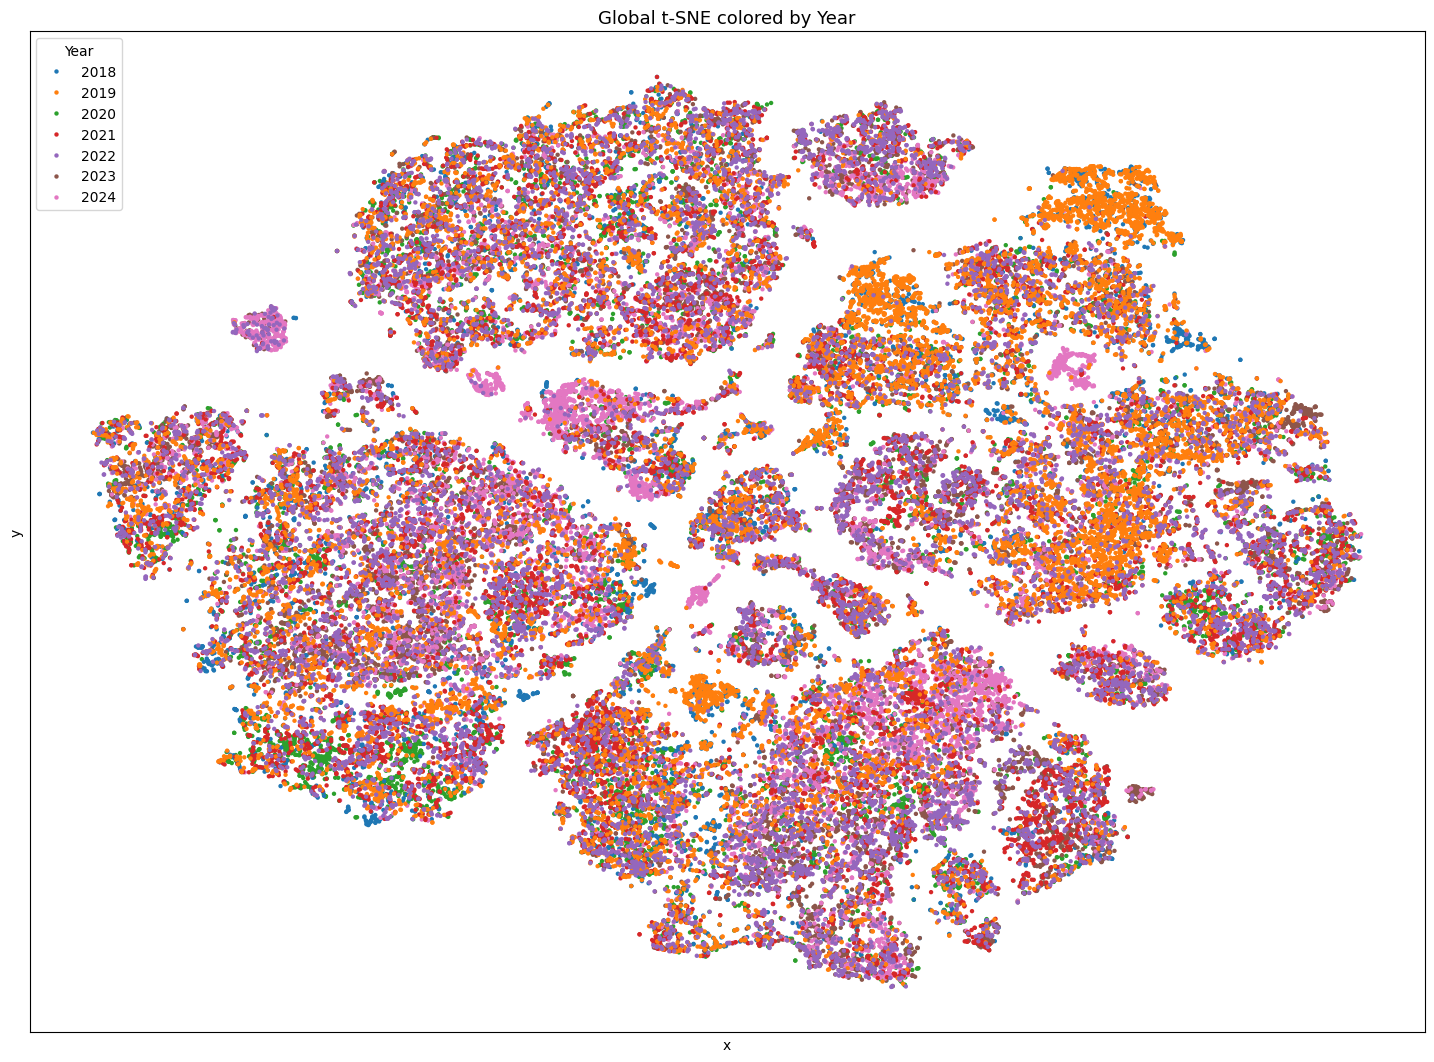

In [ ]:
fig, ax = plt.subplots(figsize=(18, 13))

sns.scatterplot(
    data=tsne_df,
    x="x", y="y",
    hue="year", hue_order=years_sorted,
    palette=sns.color_palette("tab10", n_colors=len(years_sorted)),
    s=10, linewidth=0, ax=ax
)

ax.set_title("Global t-SNE colored by Year", fontsize=13)
ax.set_xticks([]); ax.set_yticks([])
ax.legend(loc="upper left", title="Year")
plt.show()

### Year-wise t-SNE — Species Distribution per Year
Displays species clustering within each year to assess temporal consistency and potential intra-species time shifts.

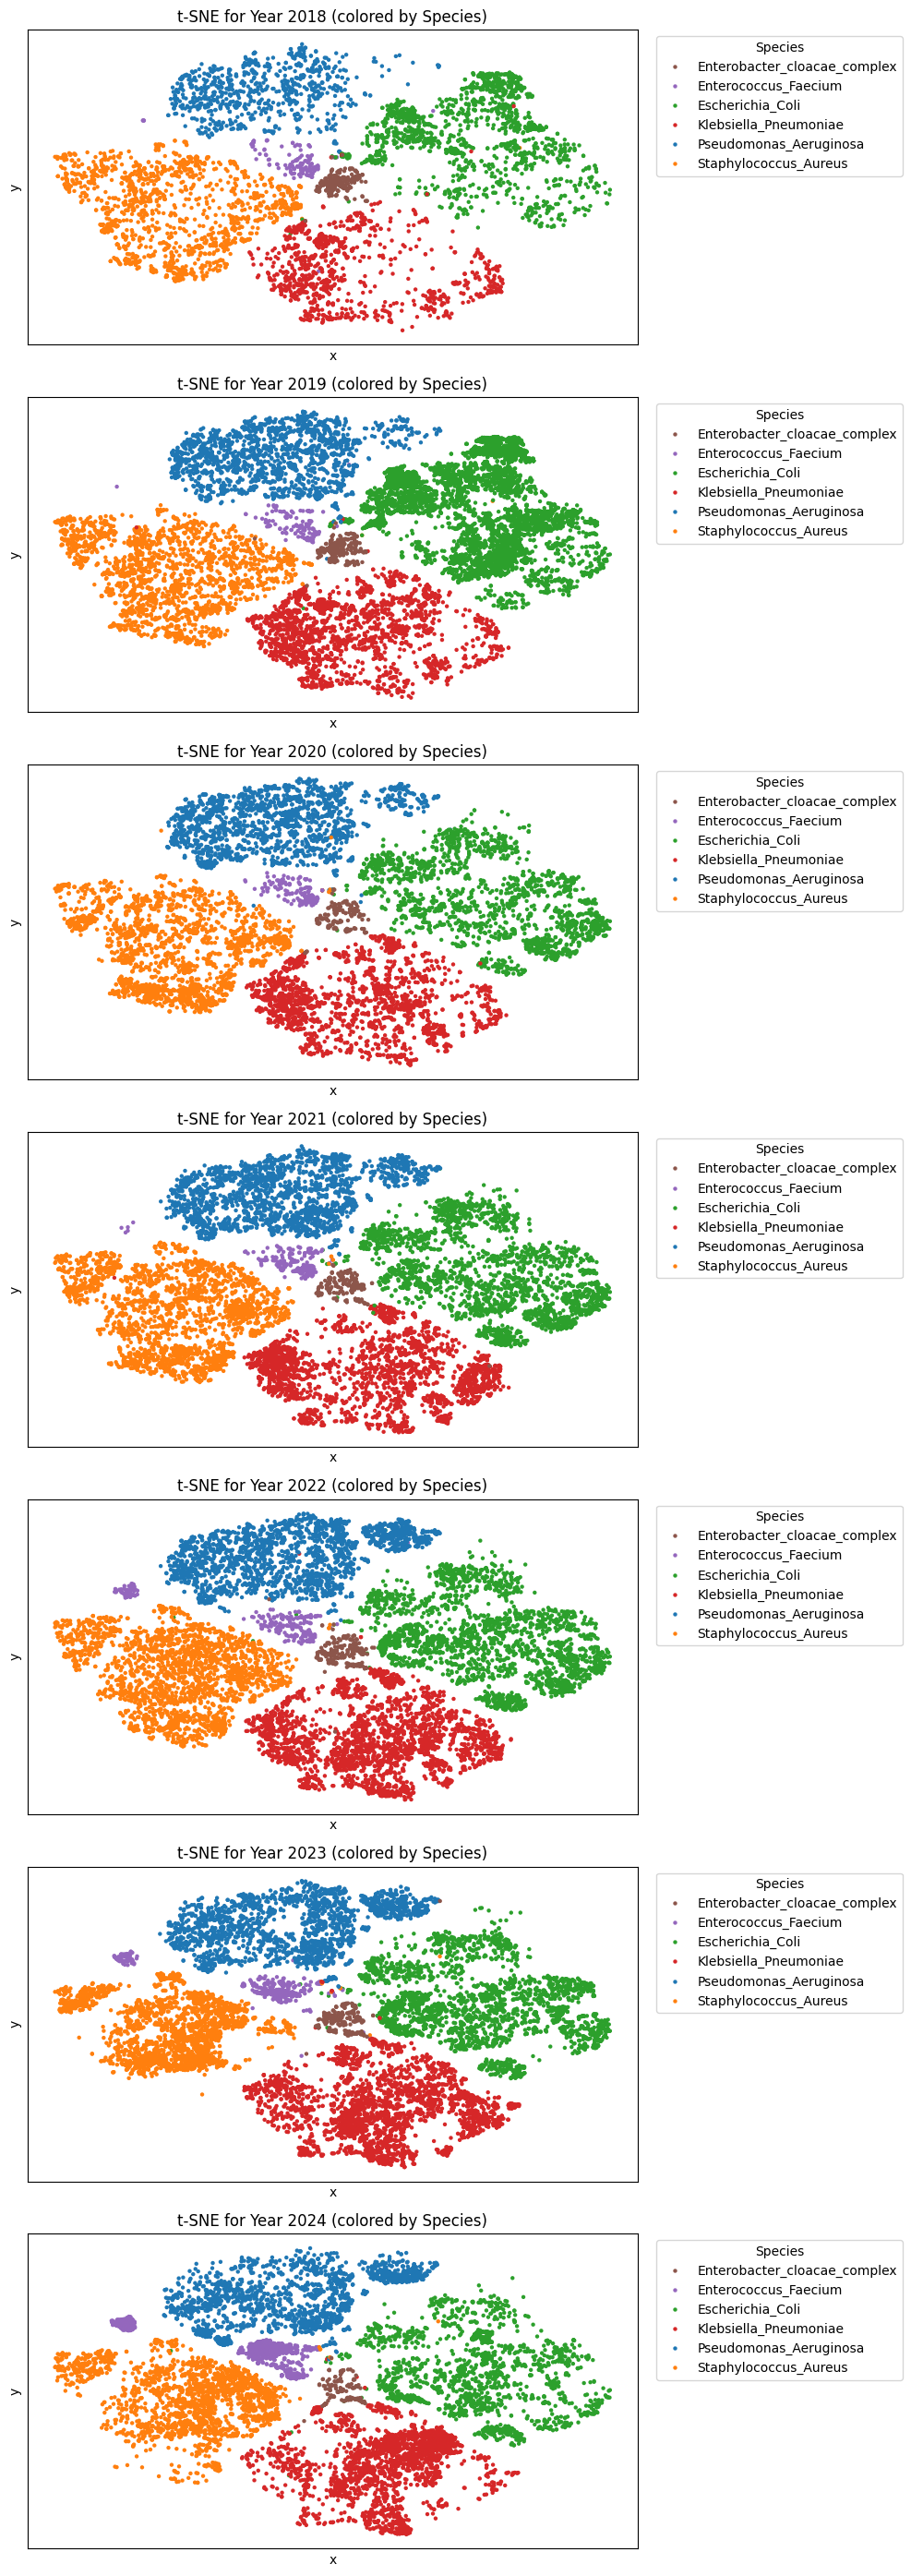

In [ ]:
fig, axes = plt.subplots(len(years_sorted), 1, figsize=(10, 4 * len(years_sorted)))

for i, year in enumerate(years_sorted):
    subset = tsne_df[tsne_df["year"] == year]
    sns.scatterplot(
        data=subset,
        x="x", y="y",
        hue="species", hue_order=species_sorted,
        palette=species_palette_dict,
        s=10, linewidth=0, ax=axes[i]
    )
    axes[i].set_title(f"t-SNE for Year {year} (colored by Species)", fontsize=12)
    axes[i].legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Species")
    axes[i].set_xticks([]); axes[i].set_yticks([])

plt.tight_layout()
plt.show()

### Independent t-SNE per Species - Temporal Distribution Analysis

In [ ]:
tsne_results_year = {}

species_sorted = sorted(np.unique(label))
years_sorted = sorted(meta["year"].astype(str).unique(), key=lambda x: int(x))

palette_year = sns.color_palette("tab10", len(years_sorted))
palette_year_dict = {y: palette_year[i] for i, y in enumerate(years_sorted)}

for sp in species_sorted:
    mask = (label == sp)

    X = data_norm[mask]
    y_year = meta.loc[mask, "year"].astype(str).values

    # PCA por especie
    X_pca = PCA(n_components=50, random_state=42).fit_transform(X)

    # t-SNE por especie
    X_tsne = TSNE(
        n_components=2,
        perplexity=30,
        random_state=42,
        init="pca"
    ).fit_transform(X_pca)

    tsne_results_year[sp] = {
        "embedding": X_tsne,
        "year": y_year
    }

print(f"Stored {len(tsne_results_year)} t-SNE embeddings (one per species, colored by year).")

Stored 6 t-SNE embeddings (one per species, colored by year).


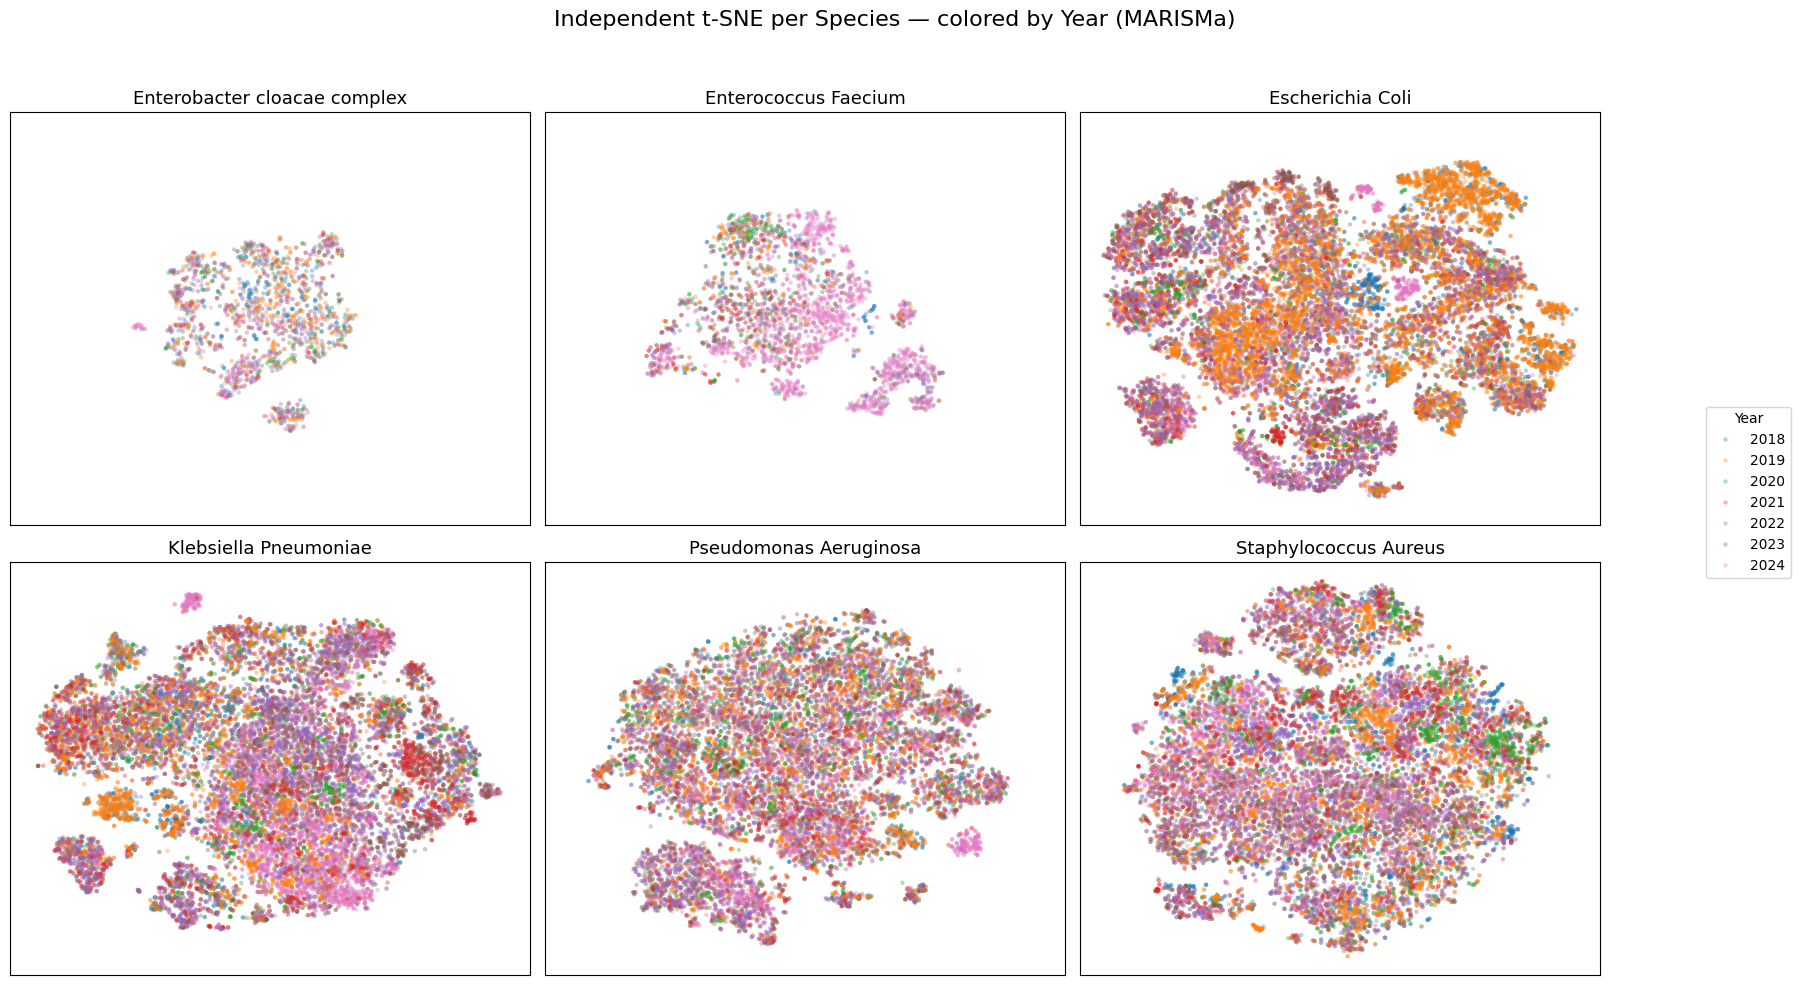

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
axes = axes.flatten()

for i, sp in enumerate(species_sorted):
    data_sp = tsne_results_year[sp]

    sns.scatterplot(
        x=data_sp["embedding"][:, 0],
        y=data_sp["embedding"][:, 1],
        hue=data_sp["year"],
        hue_order=years_sorted,
        palette=palette_year_dict,
        s=10,
        linewidth=0,
        alpha=0.35,
        ax=axes[i]
    )

    axes[i].set_title(sp.replace("_", " "), fontsize=13)
    axes[i].set_xticks([])
    axes[i].set_yticks([])
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    axes[i].legend_.remove()

# Apagar ejes sobrantes si los hay
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

# Leyenda global
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center right", title="Year")

plt.suptitle(
    "Independent t-SNE per Species — colored by Year (MARISMa)",
    fontsize=16
)
plt.tight_layout(rect=[0, 0, 0.9, 0.95])
plt.show()